# YOLO: Fine-Tuning on a Custom Dataset

## Why Fine-Tuning Matters

Training an object detector completely from scratch usually requires a large dataset, a long training run, and careful hyperparameter tuning. In practice, we usually start from a **pre-trained YOLO model** and adapt it to our own task.

This is the broad idea of **transfer learning**: reusing knowledge learned on one dataset for a new task or dataset.

A more specific term is **fine-tuning**. Fine-tuning means we continue training a pre-trained model so that its weights adapt to the new data. In other words:

- **transfer learning** is the umbrella concept,
- **fine-tuning** is one concrete way to do transfer learning.

Why this works:

- early layers already encode useful visual patterns such as edges, textures, and parts,
- we do not need to relearn those low-level features from zero,
- training becomes faster and usually needs less labelled data.

In this notebook we use `coco8`, a tiny built-in dataset, because it runs quickly. The goal is not to obtain a strong detector, but to understand the workflow:

1. inspect the dataset format,
2. check that labels align with images,
3. configure training,
4. train from pre-trained YOLO weights,
5. interpret both numeric metrics and qualitative predictions.

## Transfer Learning, Feature Extraction, and Fine-Tuning

These three terms appear together so often that they are frequently confused. They describe different points on a spectrum, not separate techniques.

### Transfer Learning

**Transfer learning** is any approach that initialises a model with weights learned on a different task or dataset rather than random values. The hypothesis is that a network that has already learned to recognise edges, textures, and object parts on ImageNet (or COCO) should need less data and fewer iterations to solve a related task.

Transfer learning does **not** specify *which* layers are updated during training. That is where feature extraction and fine-tuning come in.

### Feature Extraction vs Fine-Tuning

Once a pre-trained backbone is loaded, there are two extreme strategies:

- **Feature extraction (frozen backbone):** all backbone layers are frozen — their weights are not updated by gradient descent. Only the task-specific head is trained. The backbone acts as a fixed feature extractor, converting images into representations that the new head learns to interpret.

- **Full fine-tuning:** every layer in the network, including the backbone, is updated. The pre-trained weights are a *starting point*, not a fixed component.

In practice most workflows sit **somewhere in between**: the earliest layers are frozen (they encode very general patterns such as edges and colour gradients) and the remaining layers are updated. YOLO supports this via the `freeze` parameter:

```python
model.train(data=..., freeze=10)    # freeze the first 10 backbone layers
model.train(data=..., freeze=None)  # fine-tune everything (default)
```

### The Spectrum

| Strategy | Frozen layers | Data needed | Risk of overfitting |
|----------|--------------|-------------|---------------------|
| Train from scratch | None (random init) | Large | Low if data is large |
| Feature extraction | All backbone | Small | Lower (few free parameters) |
| Partial fine-tuning | Early backbone | Medium | Medium |
| Full fine-tuning | None | Medium-large | Higher (all parameters free) |

### Catastrophic Forgetting

When fine-tuning, the network can progressively **forget** what it learned on the source task if the learning rate is too high. This phenomenon is called **catastrophic forgetting** — the new gradients overwrite the carefully-tuned source weights too aggressively.

Practical mitigations:

- Use a **lower learning rate** than you would when training from scratch (`lr0=0.001` rather than `lr0=0.01`).
- Freeze early layers if source and target domains are similar, to reduce the number of parameters that can be corrupted.
- Add regularisation (`weight_decay`, `dropout`).
- Use early stopping via the `patience` parameter: training halts automatically if validation metrics stop improving.

### What This Notebook Actually Does

We load `yolov8n.pt` and call `model.train()` without any `freeze` argument. Every layer is eligible for gradient updates — this is **full fine-tuning**. The default learning rate is already conservative.

Because COCO and coco8 share the same class set, the head weights change very little and the backbone changes even less. In a genuine domain-transfer scenario (medical images, aerial photographs, or industrial defects) the decision of how much to freeze and what learning rate to use requires deliberately thinking through the spectrum described above.

> **Suggested project**: find a more specialised dataset and experiment with different freeze levels and learning rates to see how they affect training speed and final performance.

## Transfer Learning vs Fine-Tuning in This Notebook

There is an important caveat in this demo.

We start from `yolov8n.pt`, which was pre-trained on the COCO dataset, and we train on `coco8`, which is a tiny subset of that same general dataset family.

That means this notebook is excellent for learning the **mechanics** of YOLO training, but it is **not** a strong example of **domain transfer** to genuinely new object classes.

A more realistic custom-training scenario would involve at least one of these changes:

- a new class vocabulary,
- a very different visual domain,
- or both.

So the pedagogical interpretation should be:

- this notebook teaches the workflow of preparing, checking, training, and evaluating,
- a real custom project would require your own dataset and more careful validation.

## The YOLO data format

YOLO expects three pieces:
1. an `images/` directory,
2. a `labels/` directory,
3. a YAML file that tells the trainer where the data lives and what the class names are.

A typical custom dataset looks like this:

```text
my_dataset/
├── images/
│   ├── train/
│   └── val/
├── labels/
│   ├── train/
│   └── val/
└── data.yaml
```

Each image must have a matching label file with the same stem:
- `images/train/car_001.jpg`
- `labels/train/car_001.txt`

Each line in the label file represents one object:
`<class_id> <x_center> <y_center> <width> <height>`

Important details:
- coordinates are **normalized** to the interval `[0, 1]`, not stored in pixels,
- `class_id` is the integer index of the class in the YAML file,
- one line means one object, so an image with three objects has three lines in its `.txt` file.

## From Label Numbers to Real Boxes

YOLO label files store numbers, not drawn rectangles. To check whether the annotations make sense, we must convert those normalized values back into pixel coordinates.

That conversion is not optional bookkeeping. It is one of the most important debugging steps in detection projects, because a model will faithfully learn whatever boxes you give it, even if those boxes are wrong.

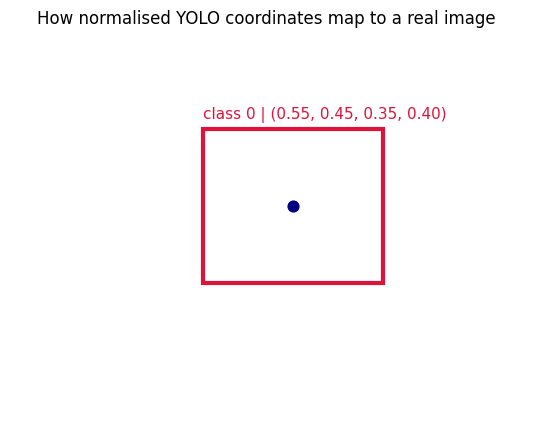

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Suppose the image has this size in pixels.
image_width, image_height = 640, 480

# Example YOLO annotation: centre x, centre y, width, height.
# These values are normalised to [0, 1].
center_x, center_y, box_width_norm, box_height_norm = 0.55, 0.45, 0.35, 0.40

# Convert normalised coordinates back to pixel coordinates.
left_x = (center_x - box_width_norm / 2) * image_width
top_y = (center_y - box_height_norm / 2) * image_height
box_width_px = box_width_norm * image_width
box_height_px = box_height_norm * image_height

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(np.ones((image_height, image_width, 3)))
rectangle = patches.Rectangle(
    (left_x, top_y),
    box_width_px,
    box_height_px,
    linewidth=3,
    edgecolor='crimson',
    facecolor='none',
)
ax.add_patch(rectangle)
ax.scatter([center_x * image_width], [center_y * image_height], color='navy', s=60)
ax.text(
    left_x,
    top_y - 12,
    f'class 0 | ({center_x:.2f}, {center_y:.2f}, {box_width_norm:.2f}, {box_height_norm:.2f})',
    color='crimson',
    fontsize=11,
)
ax.set_title('How normalised YOLO coordinates map to a real image')
ax.set_axis_off()
plt.show()

In [ ]:
from pathlib import Path

from PIL import Image
from ultralytics import YOLO
from ultralytics.data.utils import check_det_dataset
import torch
import yaml

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cpu


## Inspect the Dataset Before Training

For a real project, the first question is not "which model should I use?" but "is my dataset formatted correctly?"

We keep execution lightweight by using `coco8`, but the checks below are exactly the ones you should perform on your own data:

- confirm the YAML file resolves to the expected train and validation folders,
- inspect the class names,
- open at least one image,
- verify that the label boxes fall on the right objects.

This step is where many detection projects succeed or fail. A small dataset with correct labels is usually more valuable than a larger dataset with sloppy annotations.

In [ ]:
dataset_name = 'coco8.yaml'
dataset_info = check_det_dataset(dataset_name)

yaml_path = Path(dataset_info['yaml_file']) if 'yaml_file' in dataset_info else None
data_root = Path(dataset_info['path'])
train_dir = Path(dataset_info['train'])
val_dir = Path(dataset_info['val'])
class_names = dataset_info['names']
if isinstance(class_names, dict):
    class_names = [class_names[index] for index in sorted(class_names)]

print(f'Using dataset: {dataset_name}')
if yaml_path is not None:
    print(f'YAML file: {yaml_path}')
print(f'Dataset root: {data_root}')
print(f'Train images: {train_dir}')
print(f'Validation images: {val_dir}')
print(f'Classes: {class_names}')

Using dataset: coco8.yaml
YAML file: /media/NOCTURNOEXTRA/Alejandro/wip-clase/.venv/lib/python3.14/site-packages/ultralytics/cfg/datasets/coco8.yaml
Dataset root: /media/NOCTURNOEXTRA/Alejandro/datasets/coco8
Train images: /media/NOCTURNOEXTRA/Alejandro/datasets/coco8/images/train
Validation images: /media/NOCTURNOEXTRA/Alejandro/datasets/coco8/images/val
Classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 

The next cell prints a compact preview of the resolved dataset configuration. That is useful because YAML files can mix relative paths, dataset roots, and class dictionaries. Before training, it is worth checking that Ultralytics has resolved those fields exactly as you expect.

In [ ]:
def to_yaml_safe(value):
    if isinstance(value, dict):
        return {key: to_yaml_safe(item) for key, item in value.items()}
    if isinstance(value, list):
        return [to_yaml_safe(item) for item in value]
    if isinstance(value, tuple):
        return [to_yaml_safe(item) for item in value]
    if isinstance(value, Path):
        return str(value)
    return value


config_preview = {
    'path': dataset_info.get('path'),
    'train': dataset_info.get('train'),
    'val': dataset_info.get('val'),
    'names': dataset_info.get('names'),
}

print('Resolved dataset configuration:')
print(yaml.safe_dump(to_yaml_safe(config_preview), sort_keys=False, allow_unicode=True))

Resolved dataset configuration:
path: /media/NOCTURNOEXTRA/Alejandro/datasets/coco8
train: /media/NOCTURNOEXTRA/Alejandro/datasets/coco8/images/train
val: /media/NOCTURNOEXTRA/Alejandro/datasets/coco8/images/val
names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sandwich
  49: orange
  50: broccoli
  51: carrot
  52: hot dog
  53: pizza
  54: donut
  55: cake
  56: chair
  57: couch
 

## Visual sanity check: one image and its labels

This is one of the most valuable checks in an object-detection workflow. If the boxes are misplaced here, training will faithfully learn the wrong thing.

The cell below:
- picks one validation image,
- loads its `.txt` annotation file,
- converts YOLO coordinates back to pixel coordinates,
- overlays the boxes on the image.

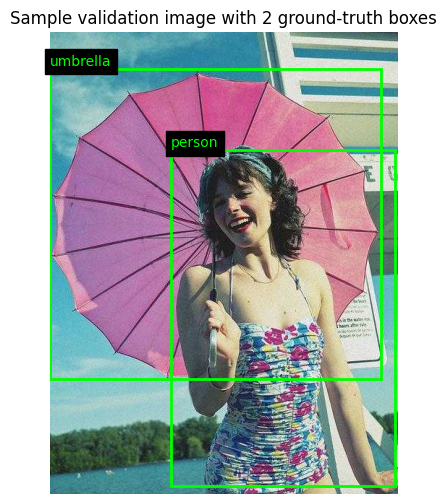

Sample image: 000000000036.jpg
Matching label file: 000000000036.txt


In [ ]:
def find_images(directory: Path) -> list[Path]:
    patterns = ('*.jpg', '*.jpeg', '*.png')
    image_paths: list[Path] = []
    for pattern in patterns:
        image_paths.extend(sorted(directory.glob(pattern)))
    return image_paths


def load_yolo_labels(label_path: Path) -> list[tuple[int, float, float, float, float]]:
    annotations: list[tuple[int, float, float, float, float]] = []
    if not label_path.exists():
        return annotations

    for line in label_path.read_text().splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        class_id, cx, cy, w, h = parts
        annotations.append((int(class_id), float(cx), float(cy), float(w), float(h)))
    return annotations


val_images = find_images(val_dir)
sample_image_path = val_images[0]
label_image = Image.open(sample_image_path).convert('RGB')
image_width, image_height = label_image.size
sample_label_path = Path(str(sample_image_path).replace('/images/', '/labels/')).with_suffix('.txt')
annotations = load_yolo_labels(sample_label_path)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(label_image)
for class_id, cx, cy, w, h in annotations:
    x1 = (cx - w / 2) * image_width
    y1 = (cy - h / 2) * image_height
    rect = patches.Rectangle(
        (x1, y1),
        w * image_width,
        h * image_height,
        linewidth=2,
        edgecolor='lime',
        facecolor='none',
    )
    ax.add_patch(rect)
    ax.text(x1, y1 - 4, class_names[class_id], color='lime', fontsize=10, backgroundcolor='black')

ax.set_title(f'Sample validation image with {len(annotations)} ground-truth boxes')
ax.set_axis_off()
plt.show()

print(f'Sample image: {sample_image_path.name}')
print(f'Matching label file: {sample_label_path.name}')

## Training Configuration

We will fine-tune `yolov8n.pt`, the **nano** version of YOLO.

What that means in practice:

- the model starts from weights learned previously on COCO,
- training continues on the target dataset instead of starting from random weights,
- the run is therefore an example of transfer learning, and more specifically fine-tuning.

Because this demo still uses `coco8`, it mainly teaches the training mechanics. A true custom project would replace `coco8` with a dataset whose classes or visual domain differ meaningfully from the original COCO pre-training data.

| Parameter | Demo value | Why it matters |
|---|---:|---|
| `model` | `yolov8n.pt` | Smaller models train faster; larger models usually achieve better accuracy. |
| `epochs` | `5` | Good for a fast demo, but far too small for most real projects. |
| `imgsz` | `640` | Higher resolution can help small objects but increases compute and memory cost. |
| `batch` | `8` | More images per update can stabilise training, but require more GPU memory. |
| `device` | `cuda` or `cpu` | GPU is much faster; CPU is acceptable only for tiny demos. |

Two useful perspectives:

- **Demo setting**: very small number of epochs so the notebook finishes quickly.
- **Real project setting**: more data, more epochs, repeated label checking, and repeated validation.

The point of this run is to understand the pipeline and the outputs, not to squeeze the best possible score from `coco8`.

In [ ]:
model = YOLO('yolov8n.pt')
run_name = 'coco8_custom_training_demo'

train_results = model.train(
    data=dataset_name,
    epochs=5,          # 5 is enough for a demo; real projects typically need 50–200.
    imgsz=640,         # Inference resolution. Affects memory quadratically (2× size = 4× RAM).
    batch=8,           # Frames per gradient update. Increase if GPU has spare memory.
    device=device,
    project='yolo_outputs',
    name=run_name,
    plots=True,        # Save loss/metric plots to the run directory.
    verbose=True,
    # patience=50,     # Early stopping: halt if mAP50 doesn't improve for N epochs.
    # lr0=0.01,        # Initial learning rate (default usually works well).
    # augment=True,    # Mosaic, flip, scale augmentations (enabled by default).
)

train_artifacts_dir = Path(model.trainer.save_dir)
print(f'Training artifacts saved to: {train_artifacts_dir}')

New https://pypi.org/project/ultralytics/8.4.34 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.22 🚀 Python-3.14.0 torch-2.10.0+cu128 CPU (Intel Core i5-10500 3.10GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=coco8_custom_training_demo2, n

## Read the training plots

Ultralytics saves figures during training, so we can inspect the run without writing much extra plotting code.

What to look for:

- **`box_loss`** (bounding-box regression loss): how far predicted boxes are from ground truth. Should decrease.
- **`cls_loss`** (classification loss): how wrong the class predictions are. Should decrease.
- **`dfl_loss`** (distribution focal loss): fine-grained box localisation quality. Should decrease.
- **Precision and Recall curves** should generally move upward.
- **mAP50 and mAP50-95** should increase over epochs.

With a tiny dataset like `coco8`, the curves may be noisy — focus on the overall direction rather than expecting perfectly smooth behavior.

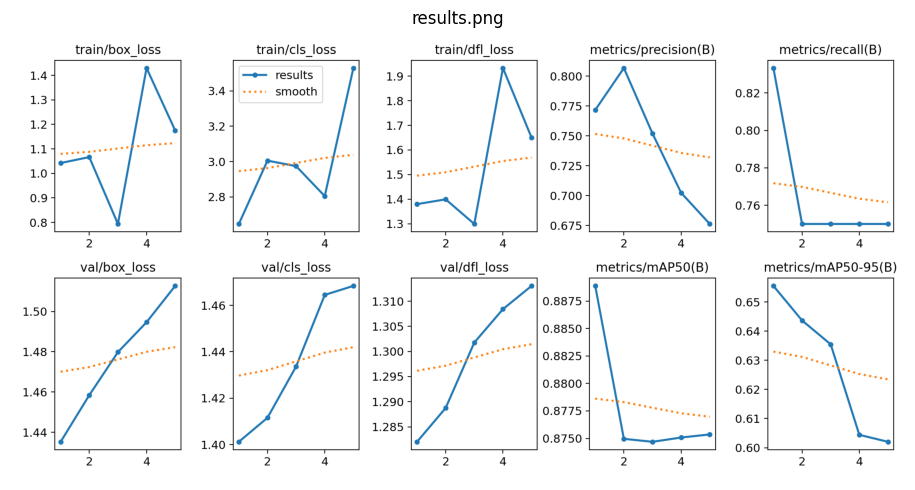

In [ ]:
results_png = train_artifacts_dir / 'results.png'

if results_png.exists():
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(Image.open(results_png))
    ax.set_title('results.png')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    print('results.png was not found in the run directory.')

## Reading the training plots

`results.png` shows one panel per logged metric across epochs. The key signals to look for:

- **`box_loss`**, **`cls_loss`**, **`dfl_loss`** (left column): training and validation losses should both decrease over epochs. A large gap between training and validation loss is a sign of overfitting.
- **Precision and Recall** (middle column): should generally rise. A model with high precision but low recall misses many objects; the opposite means it fires too often with wrong boxes.
- **mAP50 and mAP50-95** (right column): mean Average Precision at IoU threshold 0.50, and averaged over thresholds 0.50–0.95. Both should increase over epochs.

On a tiny dataset such as `coco8`, the curves will be noisy. Focus on the overall direction rather than expecting smooth monotonic behaviour.


## Evaluation metrics

After training, we evaluate on the validation set.

The two most common detection metrics are:
- **mAP50**: a prediction counts as correct if its box overlaps the ground-truth box with IoU ≥ 0.5. This is the easier metric.
- **mAP50-95**: average score over stricter IoU thresholds from 0.50 to 0.95. Better picture of box-placement quality.

A useful rule of thumb:
- if `mAP50` is much higher than `mAP50-95`, the model roughly finds objects but box placement needs improvement,
- if both are low, consider more data, cleaner labels, more epochs, or a larger model.

**Dataset split rule of thumb:** aim for roughly **80 % train / 10 % val / 10 % test**. Never evaluate on the training set — it will look perfect and tell you nothing useful.

In [ ]:
metrics = model.val(split='val')

print(f'mAP50: {metrics.box.map50:.3f}')
print(f'mAP50-95: {metrics.box.map:.3f}')
print(f'Precision: {metrics.box.mp:.3f}')
print(f'Recall: {metrics.box.mr:.3f}')

Ultralytics 8.4.22 🚀 Python-3.14.0 torch-2.10.0+cu128 CPU (Intel Core i5-10500 3.10GHz)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2166.9±872.6 MB/s, size: 54.0 KB)
val: Scanning /media/NOCTURNOEXTRA/Alejandro/datasets/coco8/labels/val.cache... 4 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4 1.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 3.4it/s 0.3s
                   all          4         17      0.771      0.833      0.889      0.655
                person          3         10      0.946        0.5      0.525      0.286
                   dog          1          1      0.639          1      0.995      0.697
                 horse          1          2      0.831          1      0.995      0.747
              elephant          1          2      0.841        0.5      0.828      0.313
              umbrella    

## Qualitative inspection of predictions

Metrics summarize the model, but they do not tell the full story. We should also inspect at least one prediction visually.

Questions to ask when you look at a prediction:
- Did the model find the right object classes?
- Are the boxes tight around the objects?
- Did it miss obvious objects?
- Are there false positives with low confidence?

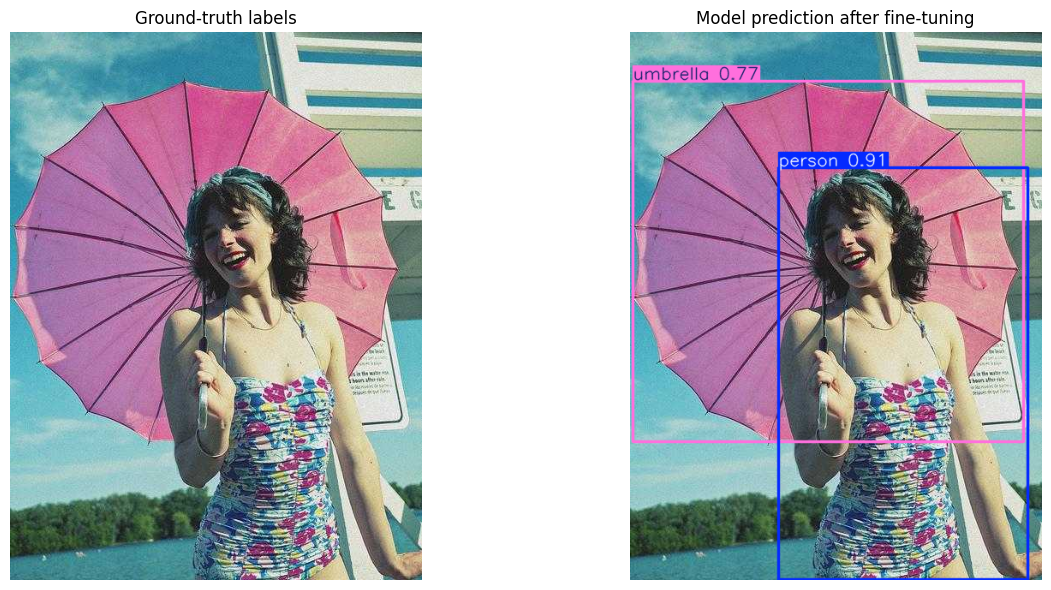

person: confidence=0.91
umbrella: confidence=0.77


In [ ]:
prediction_results = model.predict(source=str(sample_image_path), conf=0.25, verbose=False)
annotated_image = prediction_results[0].plot()[:, :, ::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(label_image)
axes[0].set_title('Ground-truth labels')
axes[0].set_axis_off()

axes[1].imshow(annotated_image)
axes[1].set_title('Model prediction after fine-tuning')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

for box in prediction_results[0].boxes[:5]:
    class_id = int(box.cls.item())
    confidence = float(box.conf.item())
    print(f'{class_names[class_id]}: confidence={confidence:.2f}')

## Inference with the fine-tuned model

Once training is complete, inference uses the same `model.predict()` interface as a pre-trained model. The difference is that the weights now reflect the dataset we just used for fine-tuning.

In a real project, this is the moment to test images that were **not** part of training and validation.

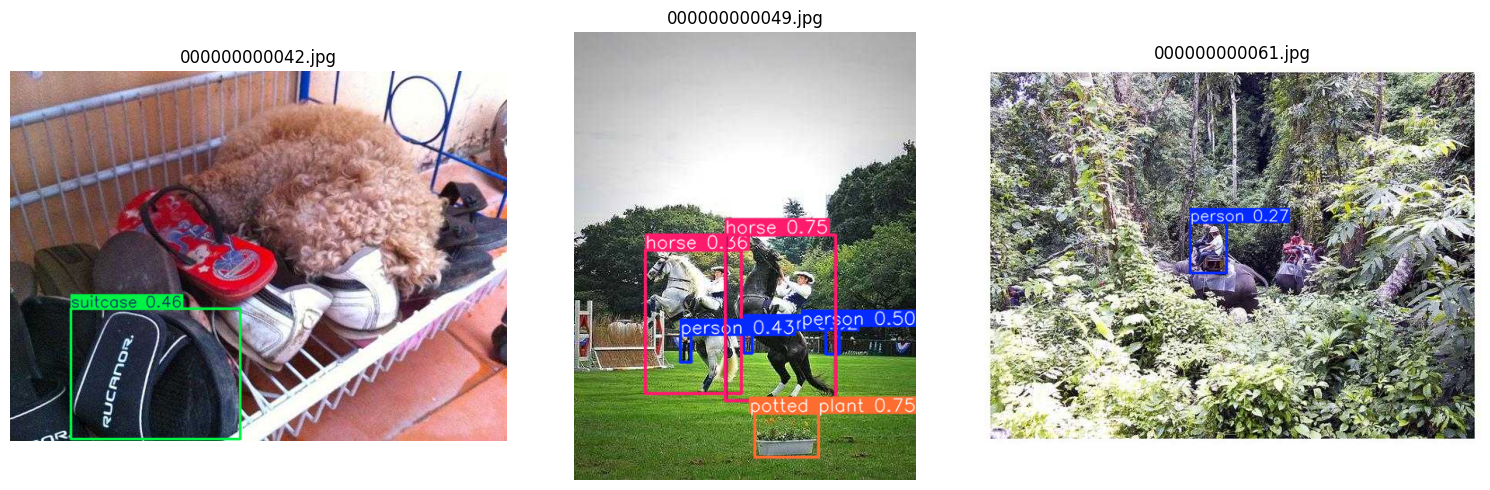

In [ ]:
extra_images = val_images[1:4]
if extra_images:
    fig, axes = plt.subplots(1, len(extra_images), figsize=(5 * len(extra_images), 5))
    if len(extra_images) == 1:
        axes = [axes]

    for ax, image_path in zip(axes, extra_images):
        result = model.predict(source=str(image_path), conf=0.25, verbose=False)[0]
        ax.imshow(result.plot()[:, :, ::-1])
        ax.set_title(image_path.name)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()
else:
    print('No extra validation images were found for inference.')

## Custom dataset YAML reference

When you switch from `coco8` to your own dataset, the YAML file becomes the contract between your files and the trainer.

A minimal example is:

```yaml
path: ../datasets/my_dataset
train: images/train
val: images/val
test: images/test  # optional

names:
  0: person
  1: bicycle
  2: car
```

Checklist before training:
- `path` points to the dataset root,
- the `train` and `val` folders actually exist,
- every image has a matching `.txt` label file,
- every `class_id` used in the labels appears in `names`,
- the boxes are normalized to `[0, 1]` and not stored in pixels.

If any of these assumptions are wrong, training may still run, but the model quality will be poor or misleading.

## Troubleshooting

Common issues in small custom-training experiments:

- **Training is very slow**: this usually means the notebook is running on CPU. That is acceptable for a tiny demo, but not for a real training workflow.
- **Metrics stay low**: the most common causes are too few epochs, too little data, or poor label quality.
- **Predictions find the object but the box is sloppy**: this often appears as a reasonable `mAP50` but a noticeably lower `mAP50-95`.
- **No detections appear**: check class IDs, label normalization, and whether the label files match the image stems.
- **The notebook runs without errors but results make no sense**: always go back to the visual sanity check cell and inspect the annotations again.

## Export for deployment

After training, we can export the model for use outside the notebook.

Why export?
- `onnx` is a common interchange format for production systems,
- deployment often happens in a different environment from training,
- exporting is the last step after we are satisfied with both the metrics and the qualitative predictions.

In [ ]:
path = model.export(format="onnx")
print(f"Model exported to {path}")

Ultralytics 8.4.22 🚀 Python-3.14.0 torch-2.10.0+cu128 CPU (Intel Core i5-10500 3.10GHz)

PyTorch: starting from '/media/NOCTURNOEXTRA/Alejandro/wip-clase/runs/detect/yolo_outputs/coco8_custom_training_demo2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 1.0s, saved as '/media/NOCTURNOEXTRA/Alejandro/wip-clase/runs/detect/yolo_outputs/coco8_custom_training_demo2/weights/best.onnx' (12.3 MB)

Export complete (1.2s)
Results saved to /media/NOCTURNOEXTRA/Alejandro/wip-clase/runs/detect/yolo_outputs/coco8_custom_training_demo2/weights
Predict:         yolo predict task=detect model=/media/NOCTURNOEXTRA/Alejandro/wip-clase/runs/detect/yolo_outputs/coco8_custom_training_demo2/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/media/NOCTURNOEXTRA/Alejandro/wip-clase/runs/detect/yolo_outputs/coco8_custom_trai

## Summary

In this notebook we followed the full fine-tuning workflow for object detection:

- understand the YOLO annotation format,
- inspect the dataset before training,
- fine-tune a pre-trained YOLO model,
- interpret training curves and validation metrics,
- inspect predictions visually,
- export the trained model.

The most important practical lesson is that **dataset quality and label correctness matter as much as model choice**.

The most important conceptual lesson is that **transfer learning** is the broad reuse of pre-trained knowledge, while **fine-tuning** is the specific act of continuing training on new data.

Finally, remember the caveat of this demo: `coco8` is ideal for learning the workflow quickly, but a real custom-training project should use genuinely custom data and a more serious validation setup.

A natural next step is to replace `coco8` with your own dataset and repeat the same inspection-first workflow.